# Антифрод ML-пайплайн

In [22]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
%matplotlib inline
from pathlib import Path

from antifraud_pipeline import (
    P,
    init_notebook,
    stage_01_load_and_profile,
    stage_02_eda_plots,
    stage_03_feature_engineering,
    stage_04_prepare_split,
    stage_05_rules,
    stage_06_llm_labeling,
    stage_07_train_models,
    stage_08_gnn,
    stage_09_neural,
    stage_10_ensemble,
    stage_11_shap,
    stage_11a_gnn_explain,
    stage_12_drift,
    stage_13_calibration,
    stage_14_retraining,
    stage_15_combined,
    stage_16_business,
    stage_17_report,
    run_all_stages,
)

init_notebook(Path.cwd())


PROJECT_ROOT: /Users/bolotnikovali/ИПС
DATA_PATH: /Users/bolotnikovali/ИПС/data/df_split_model_RF_new_features.parquet
OUTPUT_DIR: /Users/bolotnikovali/ИПС/outputs/antifraud_pipeline


## 1. Загрузка и первичный анализ

In [3]:
stage_01_load_and_profile()


  Отброшено лишних колонок из CSV: 8

Размер (только колонки как в оригинальном ноутбуке + метаданные): 4215398 × 53

resolution_fraud:
resolution_fraud
0.0    21678
1.0     1769
Name: count, dtype: int64

Доля fraud: 7.5447%, соотношение 1:12

Типы (только признаки модели, 47 полей):
float64    29
int64      18
Name: count, dtype: int64

Пропуски по признакам модели (топ-20):
                                    count  percent
password_age                       713805    16.93
loan_2d_base_limit                 381185     9.04
loan_24h_base_limit                381185     9.04
loan_1h_base_limit                 381185     9.04
puid_orders_1h_without_refunds     381185     9.04
puid_orders_24h_without_refunds    381185     9.04
puid_orders_2d_without_refunds     381185     9.04
puid_days_since_login_id_creation  187008     4.44
glue_size                          127737     3.03
glue_ead                           127737     3.03
puid_age                             1881     0.04
i_puid_k

## 2. EDA — графики

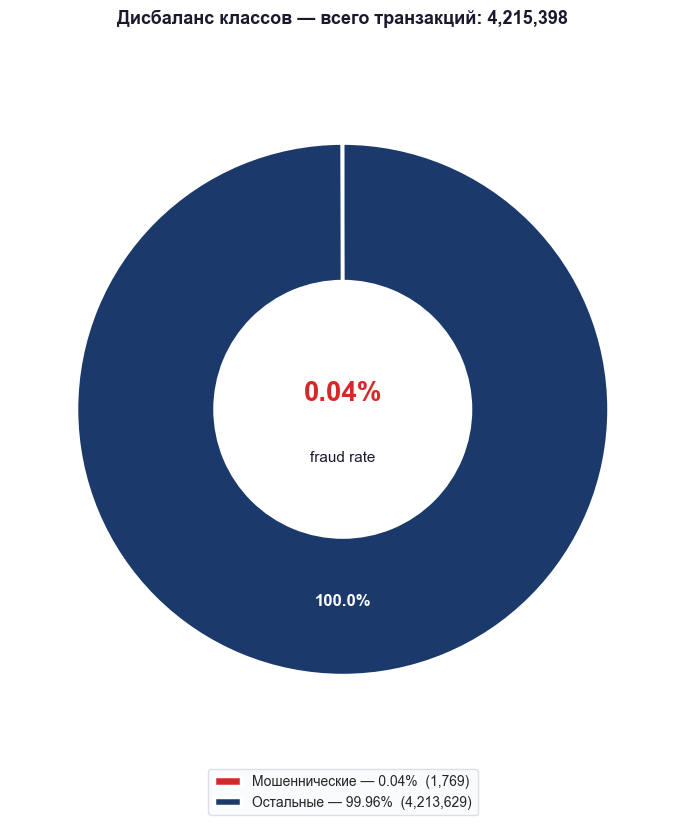

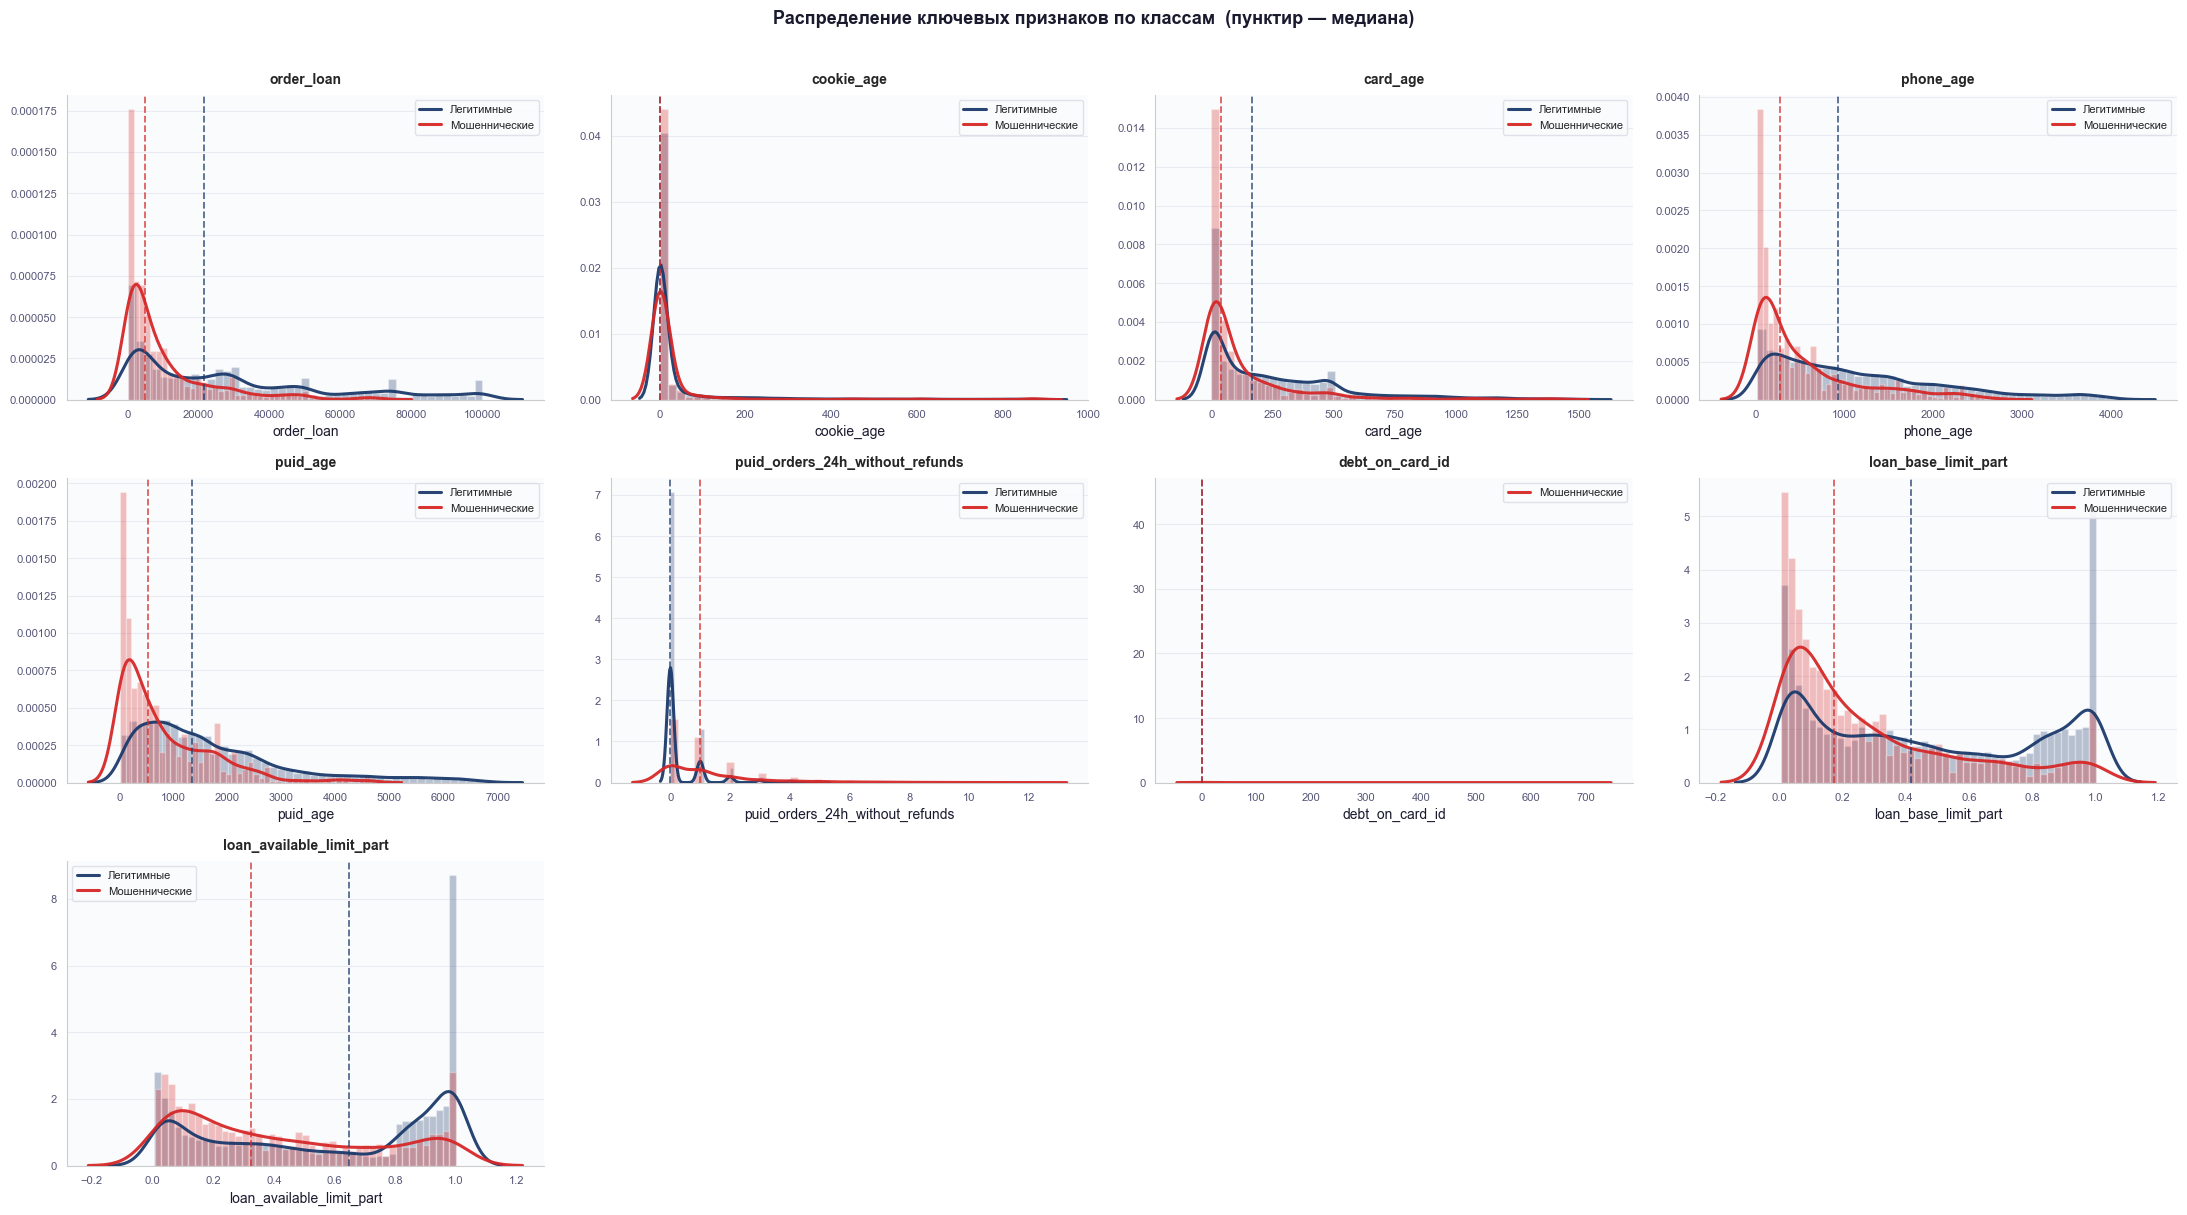

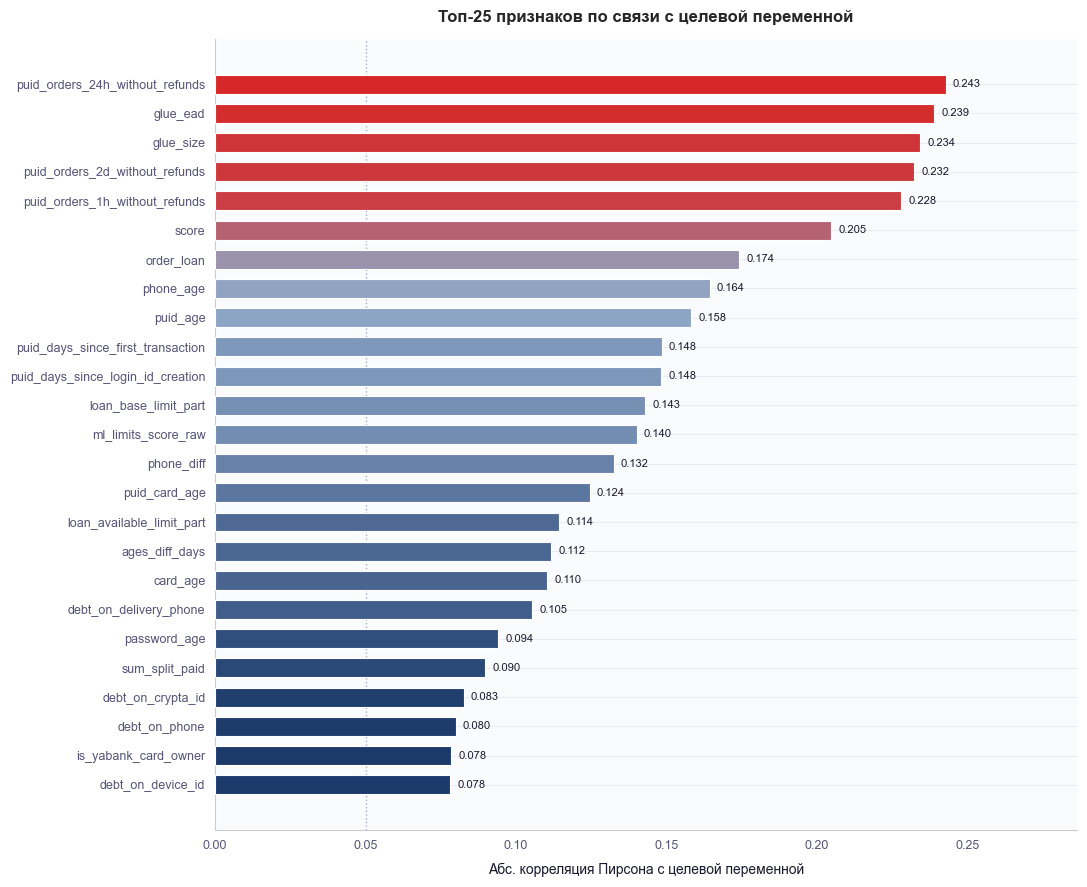

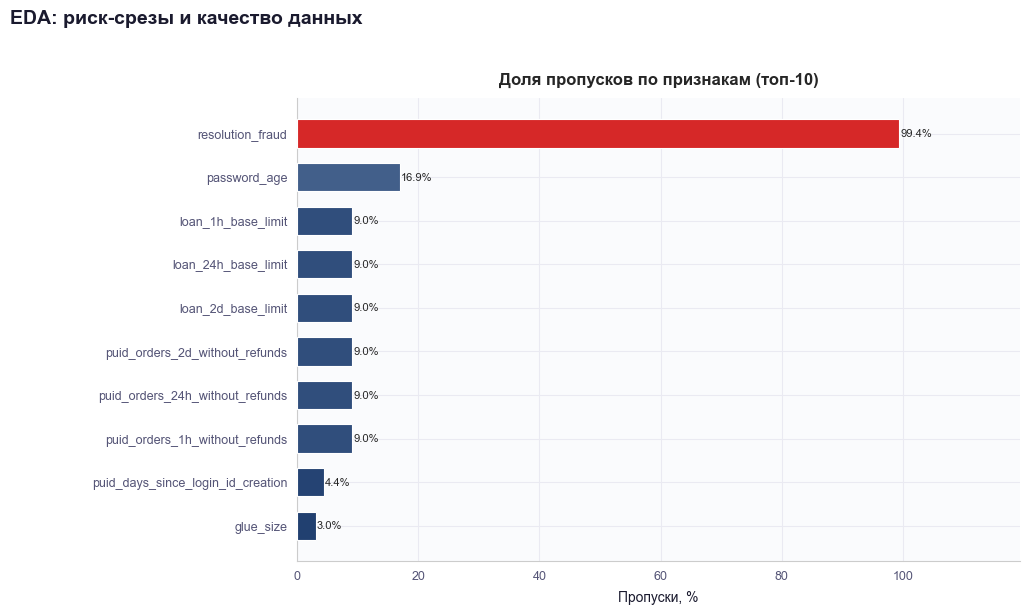

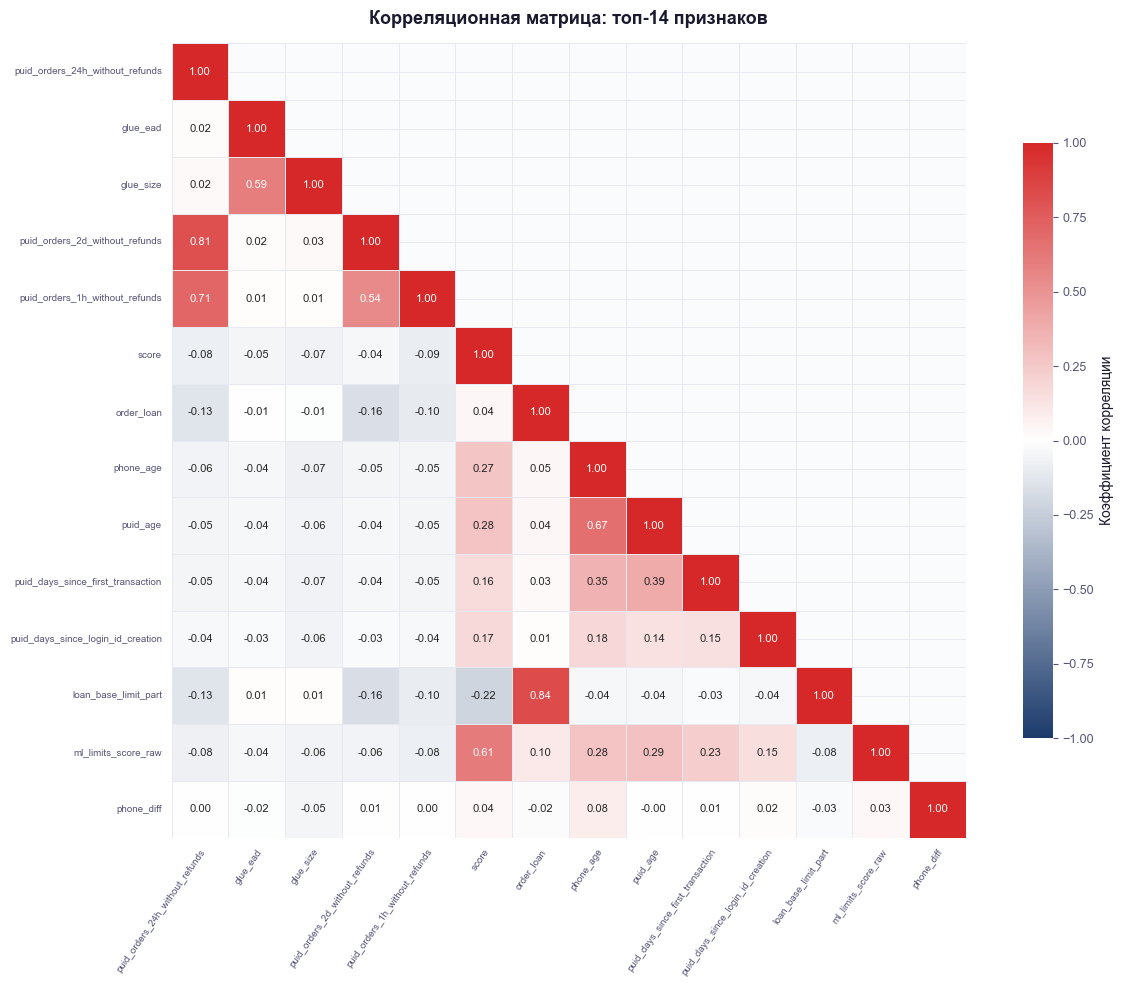


Топ-15 по |corr| с resolution_fraud:
puid_orders_24h_without_refunds      0.2428
glue_ead                             0.2390
glue_size                            0.2344
puid_orders_2d_without_refunds       0.2322
puid_orders_1h_without_refunds       0.2280
score                                0.2046
order_loan                           0.1743
phone_age                            0.1643
puid_age                             0.1582
puid_days_since_first_transaction    0.1484
puid_days_since_login_id_creation    0.1482
loan_base_limit_part                 0.1428
ml_limits_score_raw                  0.1401
phone_diff                           0.1324
puid_card_age                        0.1245
Name: resolution_fraud, dtype: float64


In [4]:
stage_02_eda_plots()


## 3. Инженерия признаков

In [5]:
stage_03_feature_engineering()


  Парсинг временных признаков...
  Создание отношений (ratio features)...
  Создание возрастных признаков...
  Создание velocity-признаков...
  Создание флагов аномалий...

  Всего создано новых признаков: 32

Размер после FE: (4215398, 86)


## 4. Сплит и подготовка матриц

In [6]:
stage_04_prepare_split()


  Удалено строк без целевой переменной (resolution_fraud): 4191951
  Идентификация столбцов...
  Числовых признаков (allowlist): 47
  Категориальных признаков (allowlist): 0
  Всего признаков: 47
  Кодирование категориальных переменных...
  Разделение на train/val/test...
  Хронологический сплит:
    Train: 15240 (8.4186% fraud)
    Val:   3517 (6.1700% fraud)
    Test:  4690 (5.7356% fraud)
    Train period: 2025-05-15 00:06:18+00:00 — 2025-06-25 05:34:14+00:00
    Val period:   2025-06-25 05:48:33+00:00 — 2025-07-07 08:16:15+00:00
    Test period:  2025-07-07 08:23:03+00:00 — 2025-07-22 23:43:07+00:00
  Обработка пропусков...

X_train (15240, 47), fraud 8.4186%
X_val   (3517, 47), fraud 6.1700%
X_test  (4690, 47), fraud 5.7356%


## 5. Правила первого уровня

In [7]:
stage_05_rules()


  Только 3 правила: extreme_velocity_1h, glue_size_spike, glue_ead_spike. Отбор на train [block]: precision, lift, доля срабатываний, мин. TP; доп. Fβ≥0.03 (β=2.0).
  Правило 'extreme_velocity_1h' [block] добавлено: prec=0.372, lift=4.42, fire=1.5%, TP=83, Fβ=0.0775
  Правило 'glue_size_spike' [block] добавлено: prec=0.731, lift=8.68, fire=0.5%, TP=57, Fβ=0.0547
  Правило 'glue_ead_spike' [block] добавлено: prec=0.623, lift=7.40, fire=0.5%, TP=48, Fβ=0.0461

  --- Статистика правил ---
  Всего транзакций: 4690
  Заблокировано правилами: 94
  Безопасно по правилам: 0
  Серая зона (→ ML): 4596
    Правило 'extreme_velocity_1h': blocked=71, safe=0
    Правило 'glue_size_spike': blocked=15, safe=0
    Правило 'glue_ead_spike': blocked=8, safe=0

  Precision блокировок по правилам: 0.3404
  Доля в серой зоне (ML): 98.00%


## 6. LLM-разметка 

  LLM: найден готовый артефакт, разметка пропущена: outputs/llm_labels.parquet
  Принудительно перезапустить LLM-разметку: FORCE_LLM_RETRAIN=1

  Успешно: 2,000/2,000   Ошибок: 0

  Распределение llm_resolution_lvl_1:
llm_resolution_lvl_1
no_negativity         1925
multiaccount            30
negative                29
social_engineering       8
client_fraud             7
unknown                  1


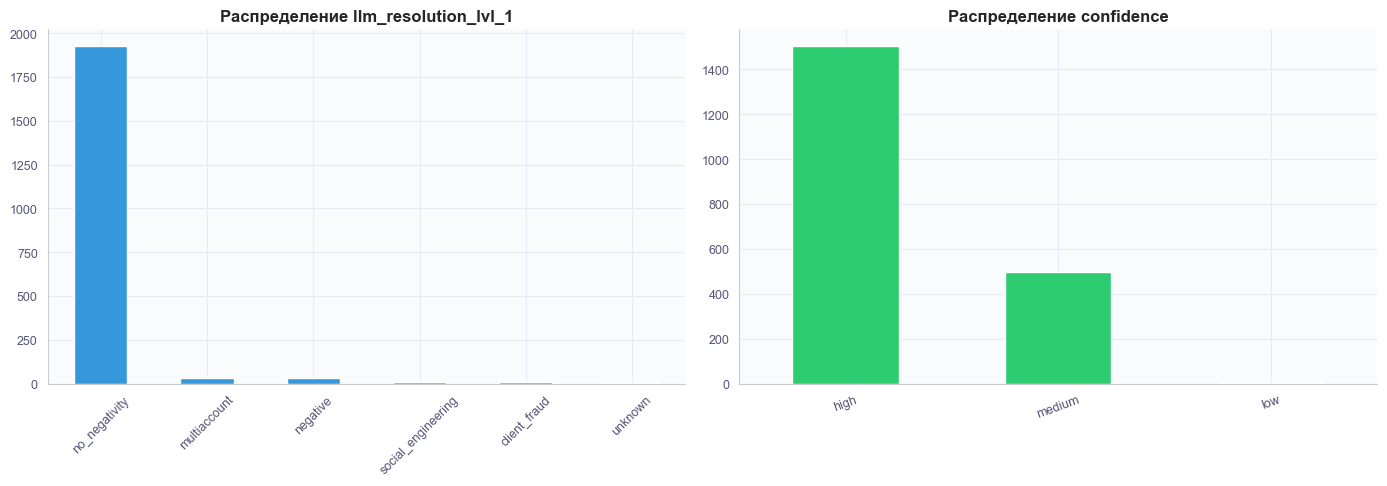


  Строк для 3-классового сравнения: 2,000
  Эскалаций LLM (все флаги = 0):    0

CLASSIFICATION REPORT (3 класса: fraud / negative / no_fraud)
              precision    recall  f1-score   support

        фрод       0.65      0.05      0.09       487
     негатив       0.53      0.09      0.15       178
без негатива       0.68      0.99      0.80      1335

    accuracy                           0.68      2000
   macro avg       0.62      0.37      0.35      2000
weighted avg       0.66      0.68      0.57      2000



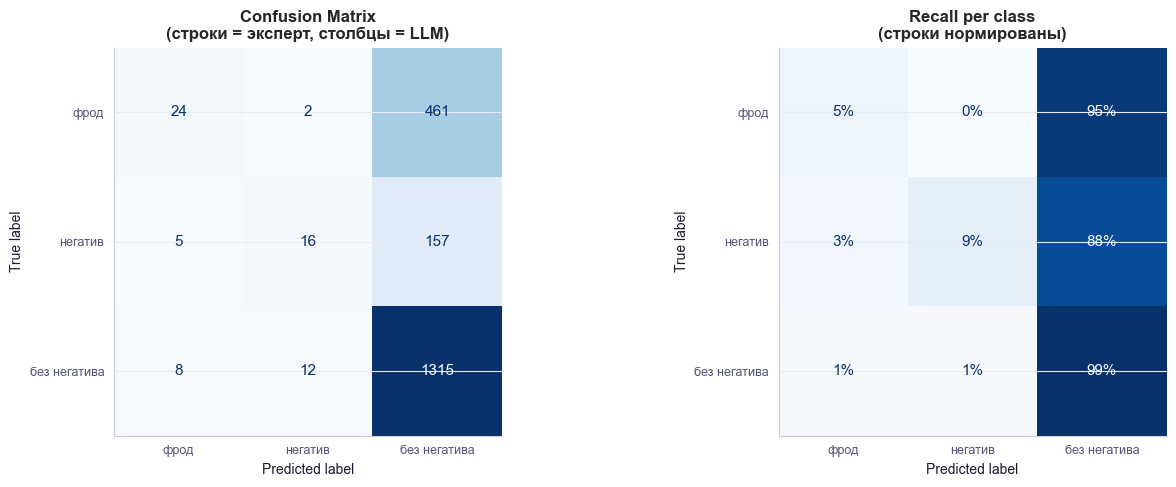


BREAKDOWN ПО УВЕРЕННОСТИ (llm_confidence)

  [HIGH]  n=1,502  accuracy=69.5%
              precision    recall  f1-score   support

        фрод       0.68      0.06      0.12       362
     негатив       0.55      0.05      0.10       115
без негатива       0.70      0.99      0.82      1025

    accuracy                           0.70      1502
   macro avg       0.64      0.37      0.34      1502
weighted avg       0.68      0.70      0.59      1502


  [MEDIUM]  n=497  accuracy=62.4%
              precision    recall  f1-score   support

        фрод       0.33      0.01      0.02       125
     негатив       0.50      0.15      0.23        62
без негатива       0.63      0.97      0.76       310

    accuracy                           0.62       497
   macro avg       0.49      0.37      0.33       497
weighted avg       0.54      0.62      0.51       497


  [LOW]  n=1  accuracy=100.0%
              precision    recall  f1-score   support

        фрод       0.00      0.00      

f1             precision             recall            
confidence     high  low medium      high  low medium   high  low medium
class                                                                   
без негатива  0.818  0.0  0.763     0.697  0.0  0.630  0.990  0.0  0.968
негатив       0.095  1.0  0.225     0.545  1.0  0.500  0.052  1.0  0.145
фрод          0.116  0.0  0.016     0.676  0.0  0.333  0.064  0.0  0.008

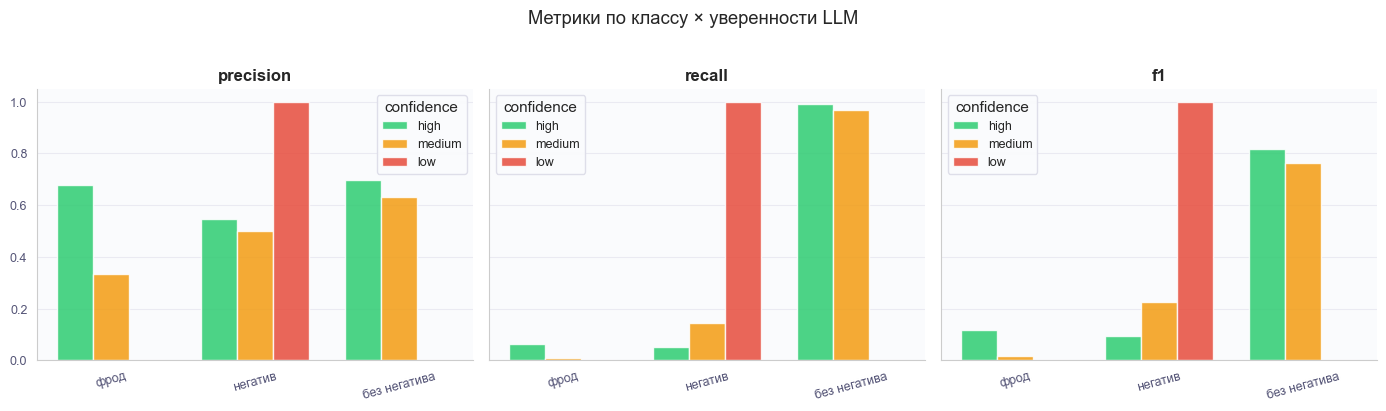


  Практический вывод:
    high  : n=1502  accuracy=70%  recall(фрод)=6%
    medium: n= 497  accuracy=62%  recall(фрод)=1%
    low   : n=   1  accuracy=100%  recall(фрод)=0%


In [8]:
import os
os.environ.pop('FORCE_LLM_RETRAIN', None)
stage_06_llm_labeling()


## 7. Обучение ML-моделей

  scale_pos_weight = 10.88

--- Логистическая регрессия (baseline) ---
  Оптимальный порог (val Fβ, β=2.0): 0.76, score=0.5396
  Test ROC-AUC: 0.8387 | PR-AUC: 0.3128 | Fβ: 0.4128


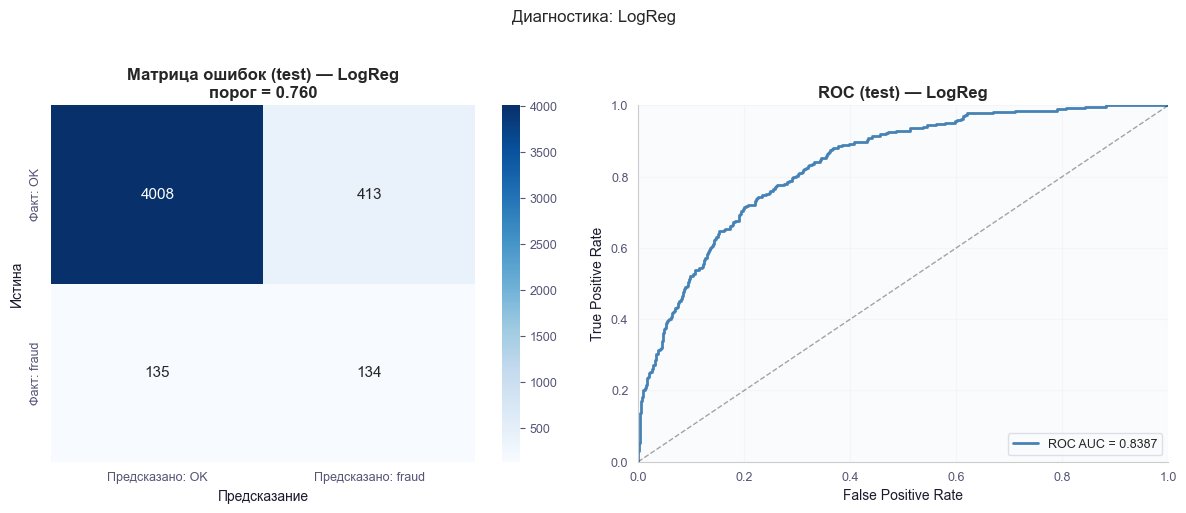

  Диагностика (CM + ROC): /Users/bolotnikovali/ИПС/outputs/antifraud_pipeline/diagnostic_cm_roc_LogReg.png

--- XGBoost ---
  Оптимальный порог (val Fβ, β=2.0): 0.48, score=0.5971
  Test ROC-AUC: 0.8579 | PR-AUC: 0.3000 | Fβ: 0.4838


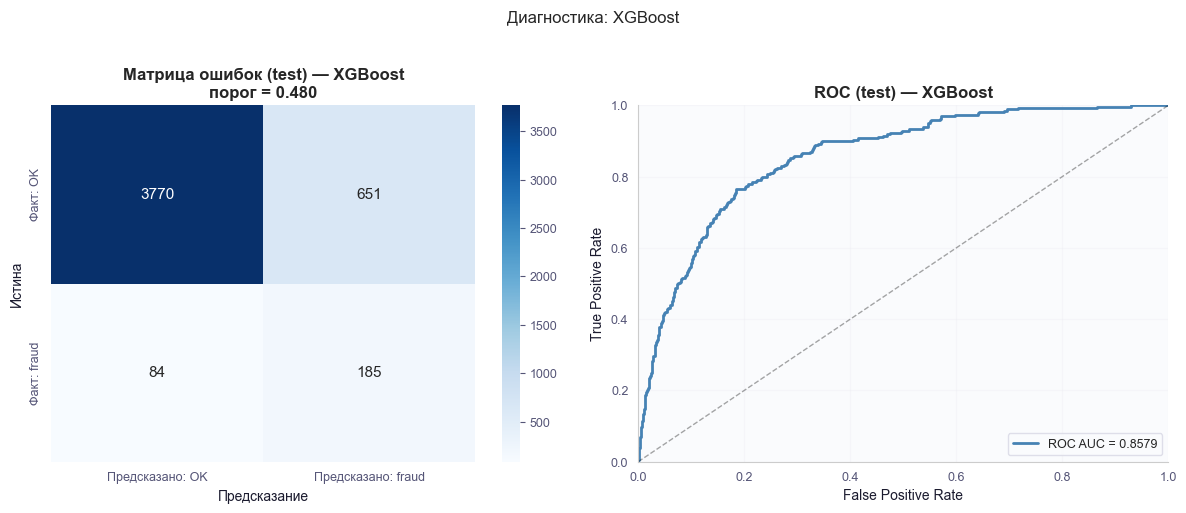

  Диагностика (CM + ROC): /Users/bolotnikovali/ИПС/outputs/antifraud_pipeline/diagnostic_cm_roc_XGBoost.png

--- LightGBM ---
  Оптимальный порог (val Fβ, β=2.0): 0.48, score=0.5899
  Test ROC-AUC: 0.8567 | PR-AUC: 0.3411 | Fβ: 0.4704


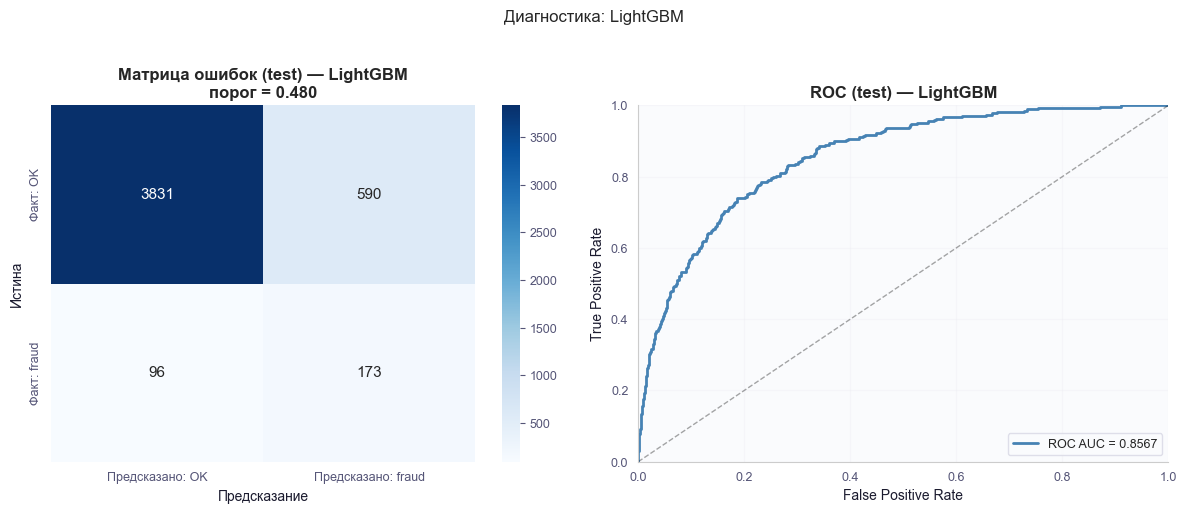

  Диагностика (CM + ROC): /Users/bolotnikovali/ИПС/outputs/antifraud_pipeline/diagnostic_cm_roc_LightGBM.png

--- CatBoost ---
  Оптимальный порог (val Fβ, β=2.0): 0.52, score=0.5951
  Test ROC-AUC: 0.8617 | PR-AUC: 0.3011 | Fβ: 0.4821


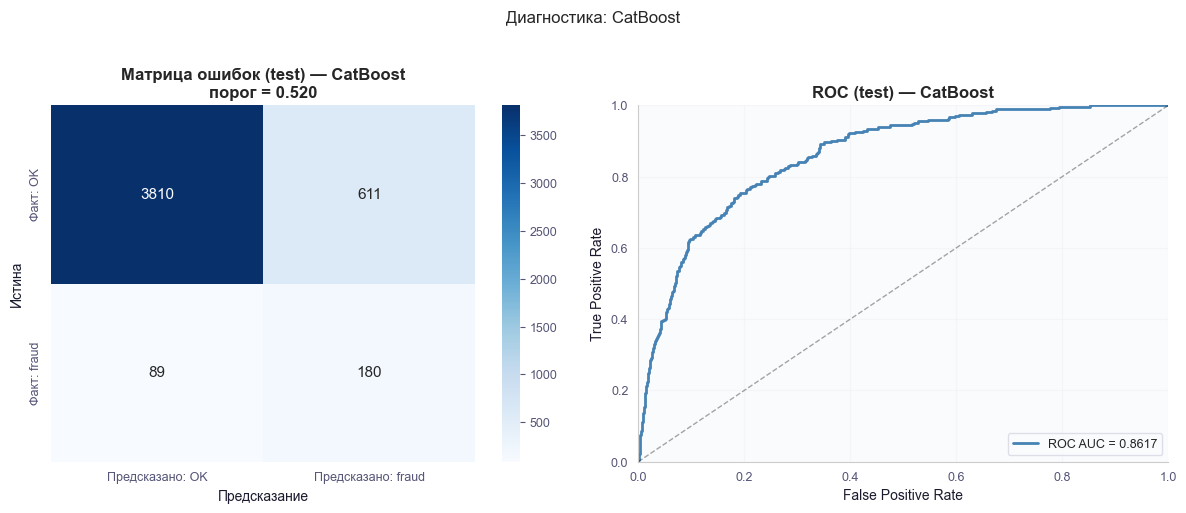

  Диагностика (CM + ROC): /Users/bolotnikovali/ИПС/outputs/antifraud_pipeline/diagnostic_cm_roc_CatBoost.png

--- XGBoost + SMOTE ---
  SMOTE: 15240 → 27914 наблюдений
  Оптимальный порог (val Fβ, β=2.0): 0.44, score=0.5578
  Test ROC-AUC: 0.8228 | PR-AUC: 0.2157 | Fβ: 0.4387


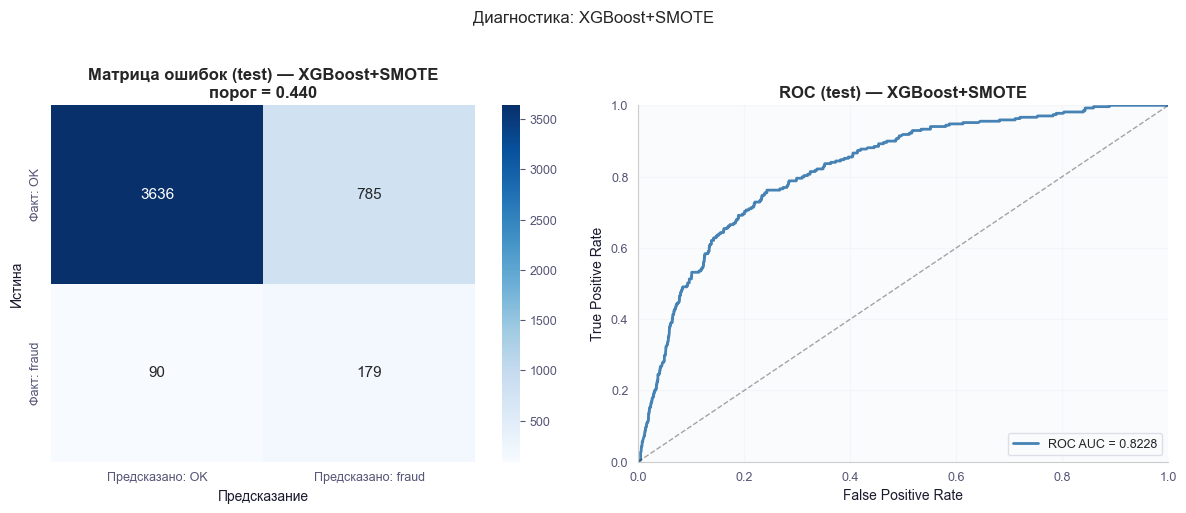

  Диагностика (CM + ROC): /Users/bolotnikovali/ИПС/outputs/antifraud_pipeline/diagnostic_cm_roc_XGBoost_SMOTE.png


In [9]:
stage_07_train_models()


## 8. GNN (GraphSAGE)

Строим граф заказов через shared entities (card_id, phone, device). Каждый заказ — узел, ребра — общие сущности. GraphSAGE агрегирует соседей и формирует скор мошенничества.


In [11]:
import os
os.environ['GNN_SUBDIR'] = 'ds1'
os.environ.pop('GNN_USE_DF_FE', None)
os.environ.pop('FORCE_GNN_RETRAIN', None)
print(f"GNN_SUBDIR={os.environ.get('GNN_SUBDIR')}  scores={__import__('pathlib').Path('outputs/gnn/ds1/gnn_scores.parquet').exists()}")
stage_08_gnn()


GNN_SUBDIR=ds1  scores=True
  GNN директория: outputs/gnn/ds1
  GNN: быстрая загрузка — граф не перестраивается
  best_epoch=36, best_val_Fβ=0.5799
  Граф не загружен (для GNNExplainer: GNN_LOAD_GRAPH=1 или FORCE_GNN_RETRAIN=1)
  Скоры загружены из чекпойнта: outputs/gnn/ds1/gnn_scores.parquet  (4,215,398 заказов)

TEST  GraphSAGE  (порог по val Fβ = 0.68)
F_β (β=2.0):  0.4976
PR-AUC:         0.3248
ROC-AUC:        0.8706

              precision    recall  f1-score   support

   non-fraud       0.98      0.85      0.91      4421
       fraud       0.23      0.71      0.34       269

    accuracy                           0.85      4690
   macro avg       0.60      0.78      0.63      4690
weighted avg       0.94      0.85      0.88      4690

  GraphSAGE в табличном leaderboard (val/test как у GBM): Fβ=0.4976  PR-AUC=0.3248


## 9. Нейросети

In [12]:
stage_09_neural()


  Импорт torch (при первом запуске в сессии может занять 1–3 минуты)...
  PyTorch 2.11.0, потоков torch: 1, нейросети→cpu (на Mac по умолчанию cpu вместо mps; для MPS: env ANTIFRAUD_TORCH_DEVICE=mps)

--- Автоэнкодер (Anomaly Detection) [device=cpu] ---
  Подготовка данных: признаков=47, легитимных строк для обучения AE≈13957, тест=4690 строк (дальше масштабирование — может занять несколько минут на больших данных).
  Фильтрация y==0 и извлечение матрицы...
  StandardScaler.fit_transform на 13957×47...
  Готово train. StandardScaler.transform теста (4690 строк)...
  Копирование train в torch.FloatTensor (память + время)...
  Train-тензор готов, shape=(13957, 47), device=cpu → батчи пойдут на cpu
  Старт обучения AE: признаков=47, объектов=13957, батчей/эпоха=27, drop_last=True, эпох=30
  [AE] эпоха 1/30 ... [5/27 loss=1.0671] [10/27 loss=1.0807] [15/27 loss=0.9682] [20/27 loss=1.1086] [25/27 loss=0.9628] [27/27 loss=1.0792]  →  avg_loss=1.110262  lr=1.00e-03
  [AE] эпоха 2/30 ... [5/27

<!-- Пункт 11 удалён: сравнение дублируется в stage_13_ensemble -->


## 10. Ансамбли

  NN_Classifier добавлен в ансамбль.
  GraphSAGE добавлен в ансамбль (avg / rank / stack вместе с GBM/NN).
--- Ансамблирование ---
  Simple Average — ROC-AUC: 0.8729, PR-AUC: 0.3409
  Веса: {'XGBoost': 0.19, 'LightGBM': 0.216, 'CatBoost': 0.191, 'NN_Classifier': 0.197, 'GraphSAGE': 0.206}
  Weighted Average — ROC-AUC: 0.8732, PR-AUC: 0.3426
  Rank Average — ROC-AUC: 0.8745, PR-AUC: 0.3431

  Стекинг (LogReg на мета-признаках):
  Stacking LogReg — ROC-AUC: 0.8848, PR-AUC: 0.3619

  Fβ (β=2.0) на test при пороге с val: Simple=0.5028 Weighted=0.5088 Rank=0.5141 Stacking=0.5151
  Лучший ансамбль (по Fβ): Stacking
  BestEnsemble (Stacking) — ROC-AUC: 0.8848 | PR-AUC: 0.3619 | Fβ: 0.5151

--- То же ансамблирование без NN_Classifier (сравнение с полным составом) ---
  BestEnsemble_no_NN (Stacking) — ROC-AUC: 0.8831 | PR-AUC: 0.3659 | Fβ: 0.5274
  Сводка Fβ на test (порог с val): с NN — 0.5151, без NN — 0.5274 (Δ=+0.0124)

--- Итоговое сравнение всех моделей (включая NN и ансамбль) ---

--- Ср

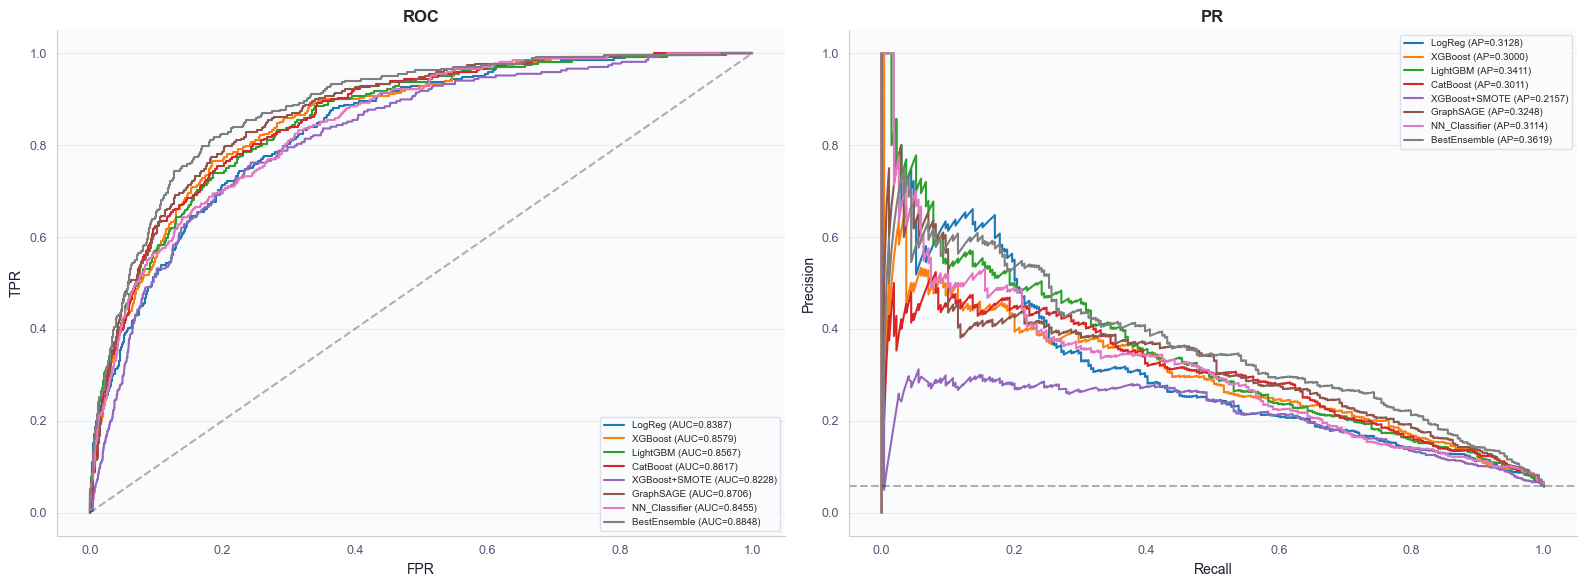

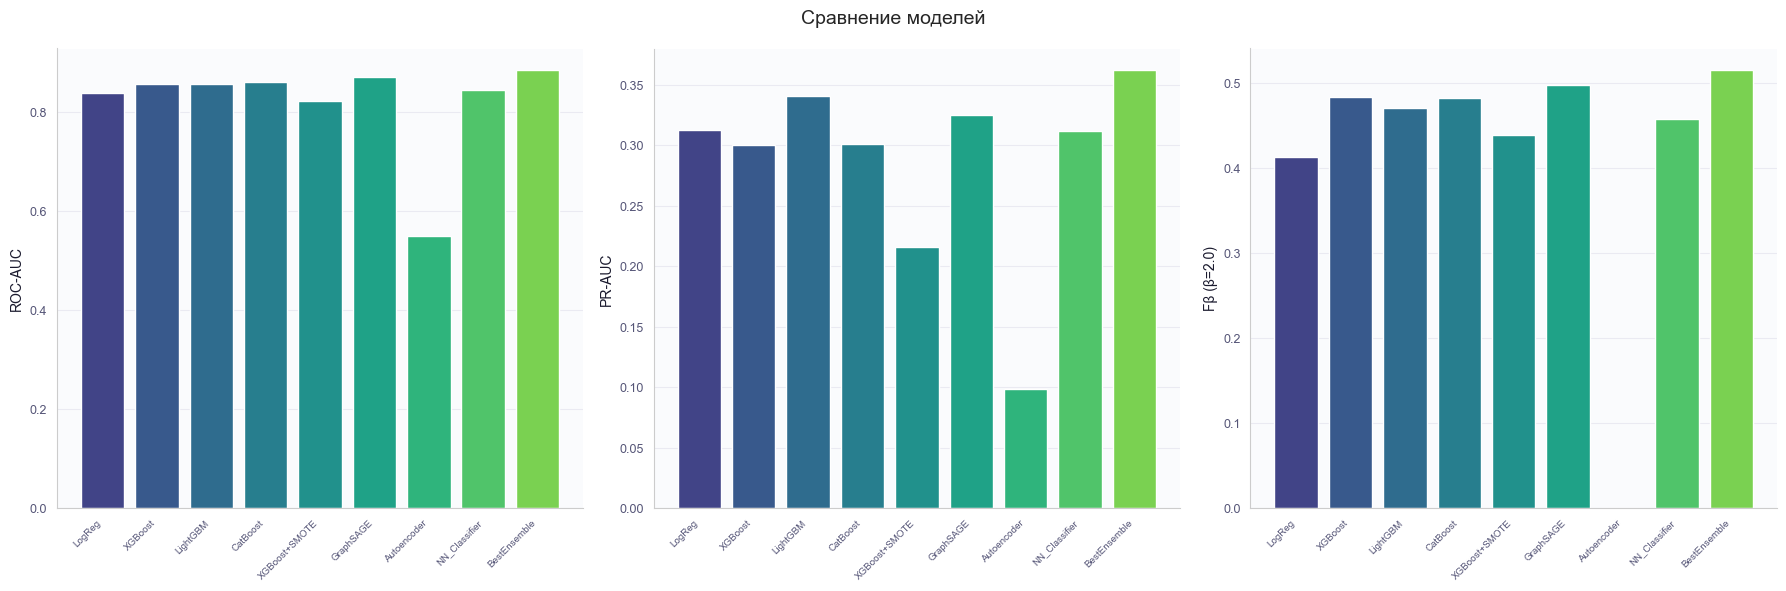

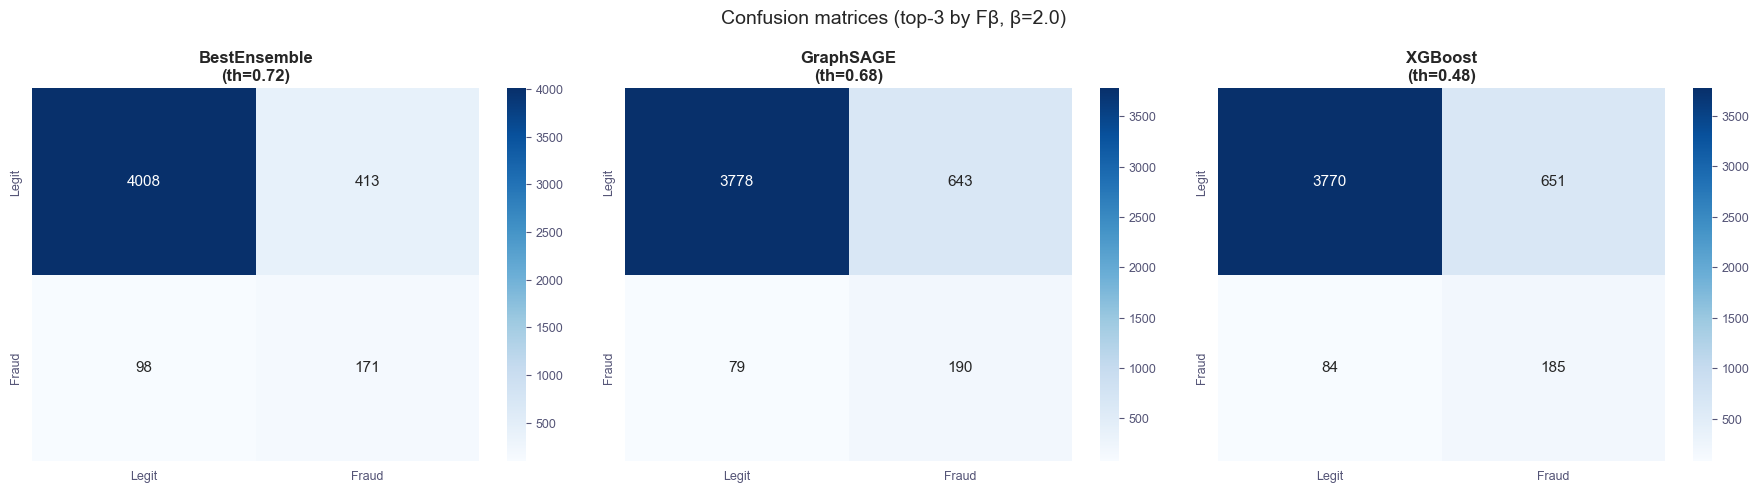

In [13]:
stage_10_ensemble()


## 11. SHAP — объяснимость 

Модель для SHAP: XGBoost (Fβ, β=2.0=0.4838)

  Вычисление SHAP для XGBoost...
  SHAP shape: (800, 47)


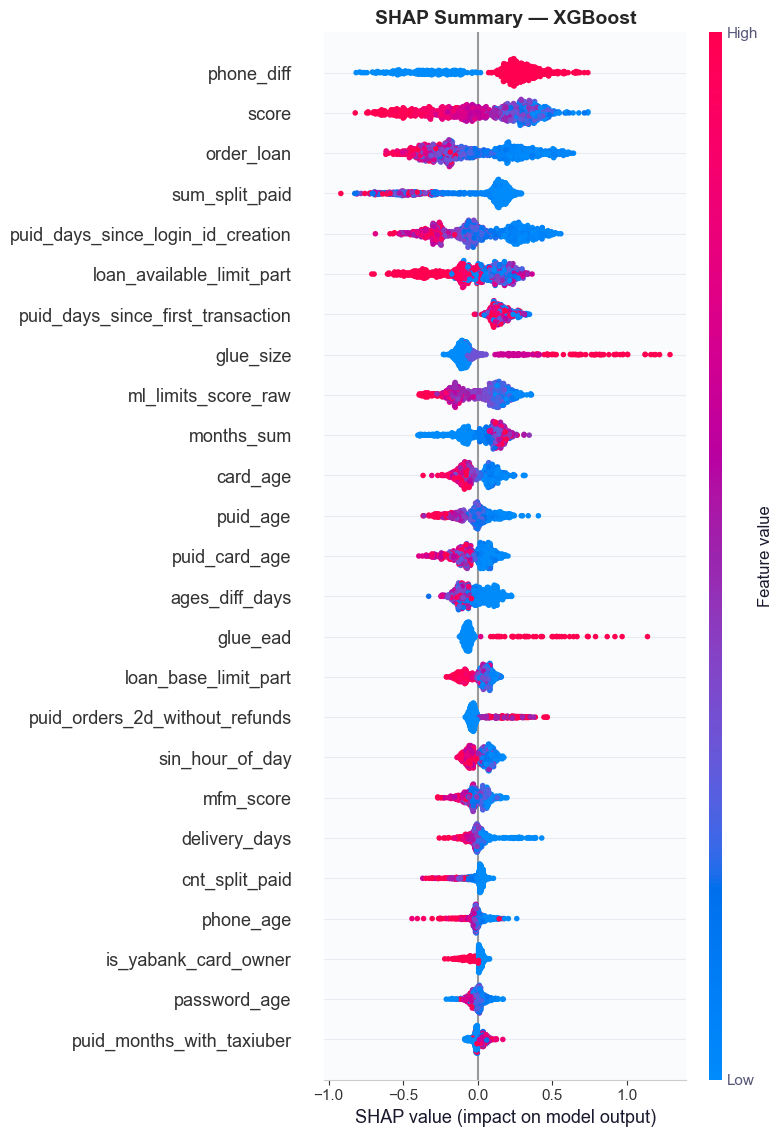

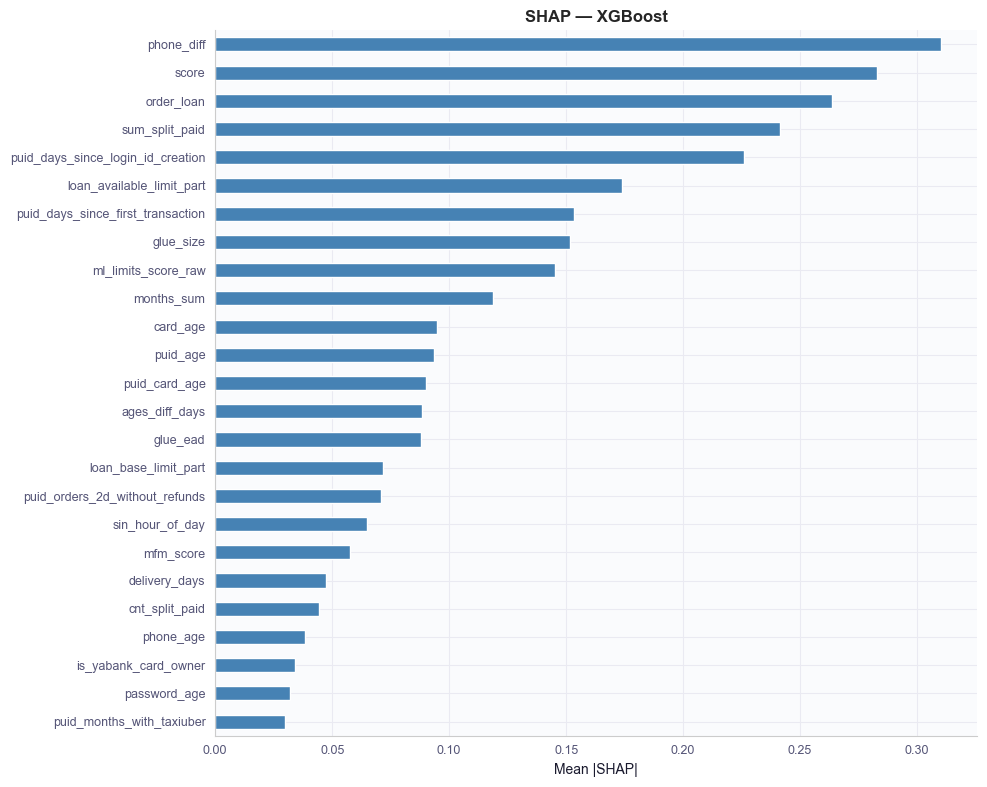

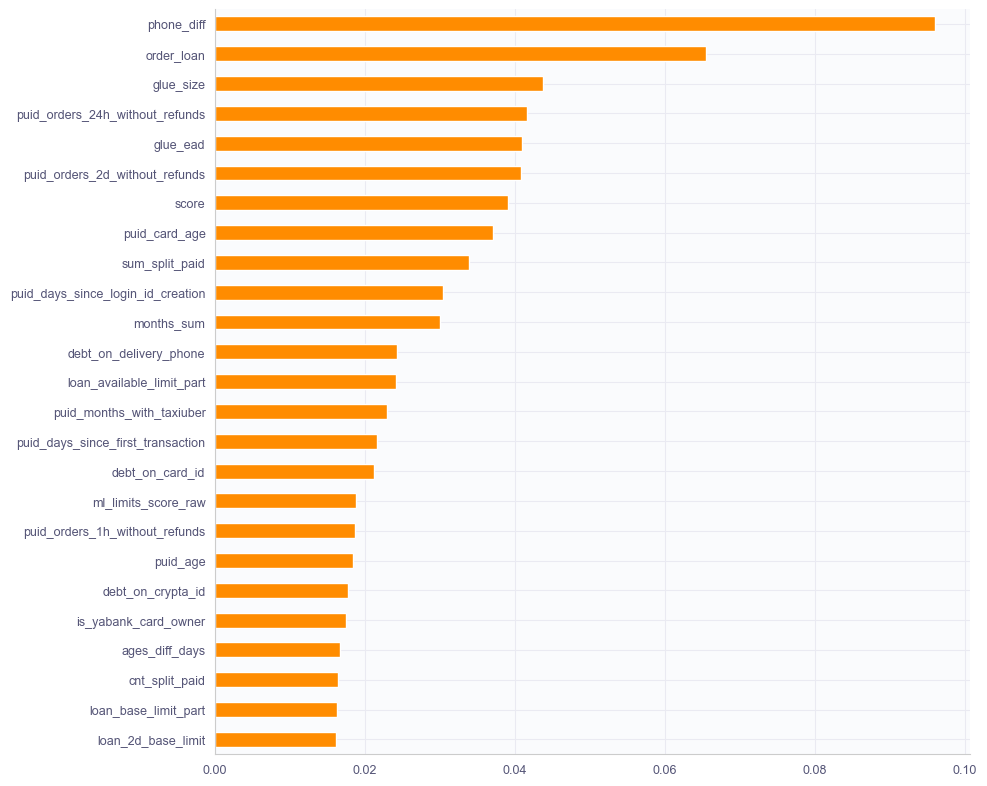

In [14]:
stage_11_shap()


### 11.1 GNNExplainer — объяснимость GNN

Для каждого узла GNNExplainer находит подграф и признаки, наиболее влияющие на предсказание.


  GNN загружен из чекпойнта без графа — показываю сохранённые объяснения.
  gnn_explain_node_3276081.png


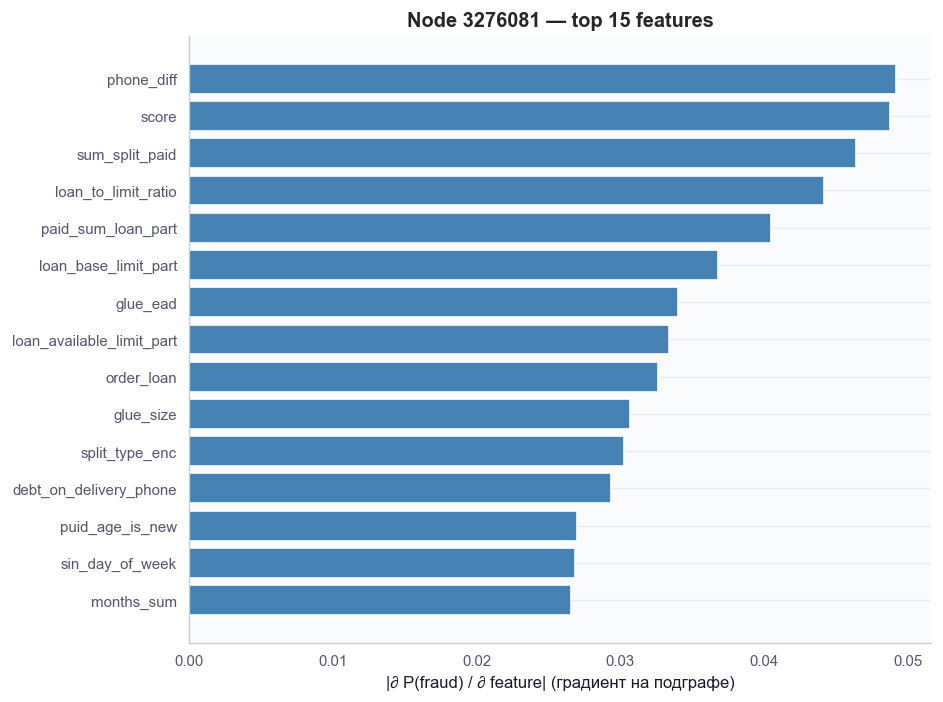

In [24]:
stage_11a_gnn_explain()


## 12. Мониторинг дрейфа

Дрейф признаков: 10
Рекомендация: OK


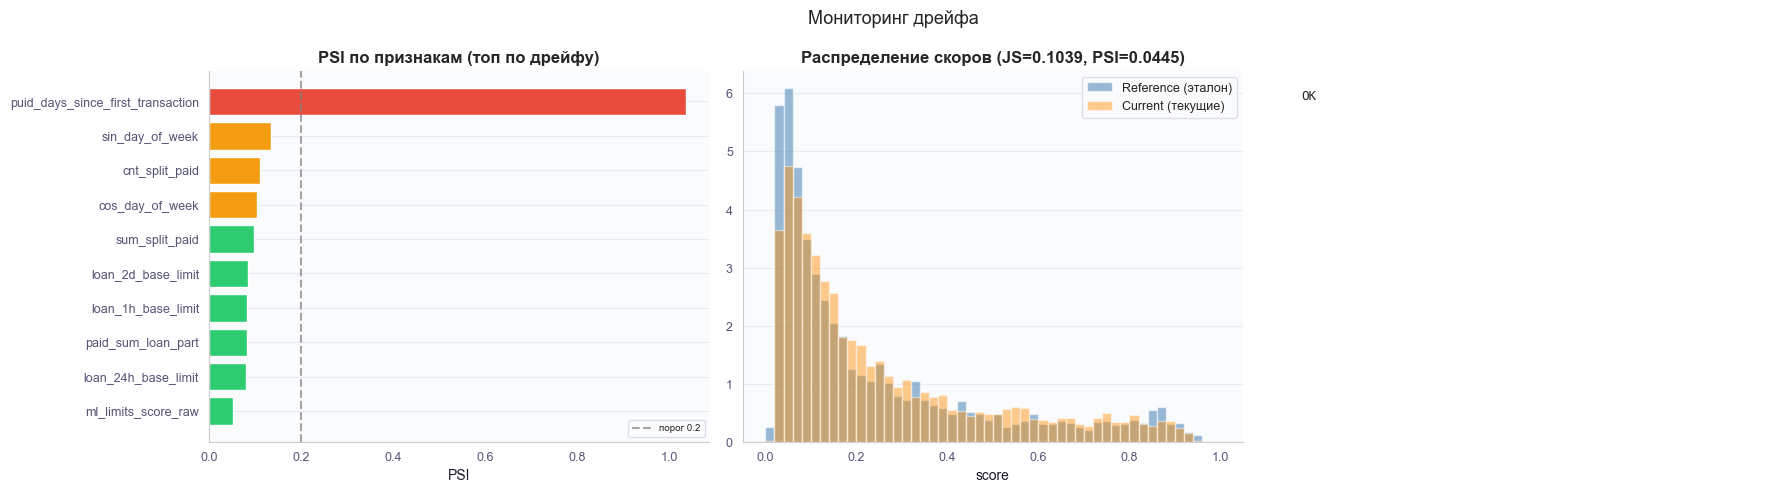

In [16]:
stage_12_drift()


## 13. Калибровка


  Калибровка XGBoost...


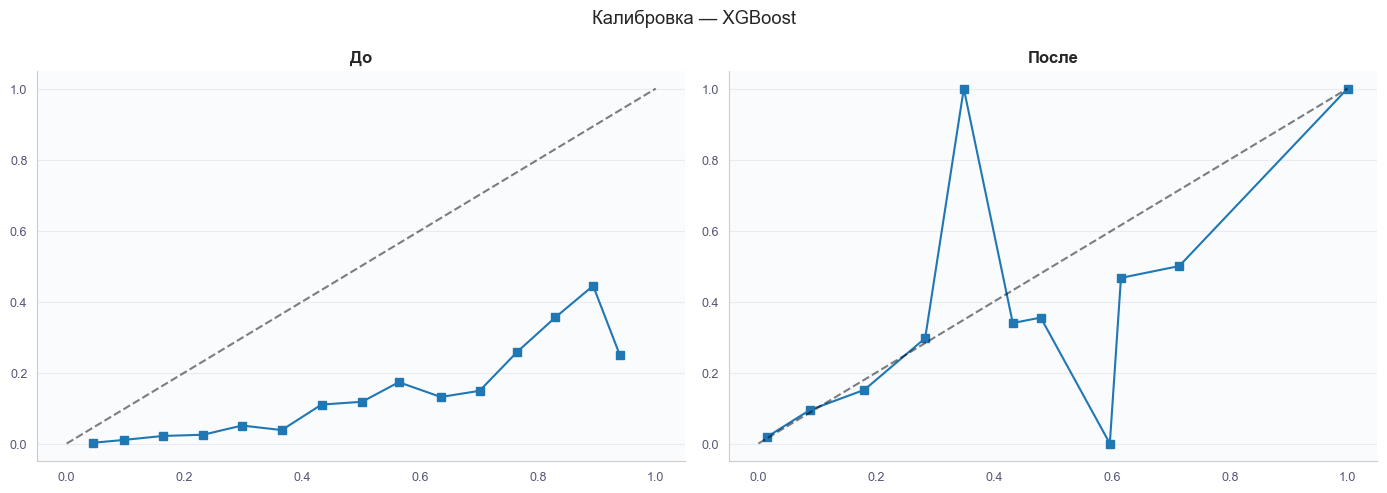

  Brier raw: 0.107799 | cal: 0.046661


In [17]:
stage_13_calibration()


## 14. Дообучение

In [18]:
stage_14_retraining()


  Champion Fβ (β=2.0): 0.4838 | Challenger: 0.4828 | Δ: -0.0009
  Чемпион не заменён: нужен прирост Fβ ≥ min_improvement=0.001 (сейчас -0.0009). Иначе смена модели шумит на тесте.


## 15. Комбинированный пайплайн

In [19]:
stage_15_combined()


  Перед Combined: выполнен тихий единый пересчёт метрик (пороги с val).
  Combined: ML = XGBoost (Fβ=0.4838 — лучшая по Fβ на test среди доступных ML-моделей; не SHAP-only)

  Распределение решений:
    ml_block: 785 (16.74%), fraud rate: 20.0000%
    ml_pass: 3811 (81.26%), fraud rate: 2.0992%
    rule_block: 94 (2.00%), fraud rate: 34.0426%

  ROC-AUC: 0.8569 | PR-AUC: 0.2650 | Fβ (β=2.0): 0.4834 | F1: 0.3293
  Precision: 0.2150 | Recall: 0.7026 | FPR: 0.1561


## 16. Бизнес-метрики

  fraud_prevented_count: 185
  fraud_prevented_amount: 9,250,000
  fraud_missed_count: 84
  fraud_missed_amount: 4,200,000
  false_blocks_count: 651
  false_block_costs: 1,302,000
  review_costs: 418,000
  total_costs: 5,920,000
  net_savings: 7,530,000
  roi: 1.27


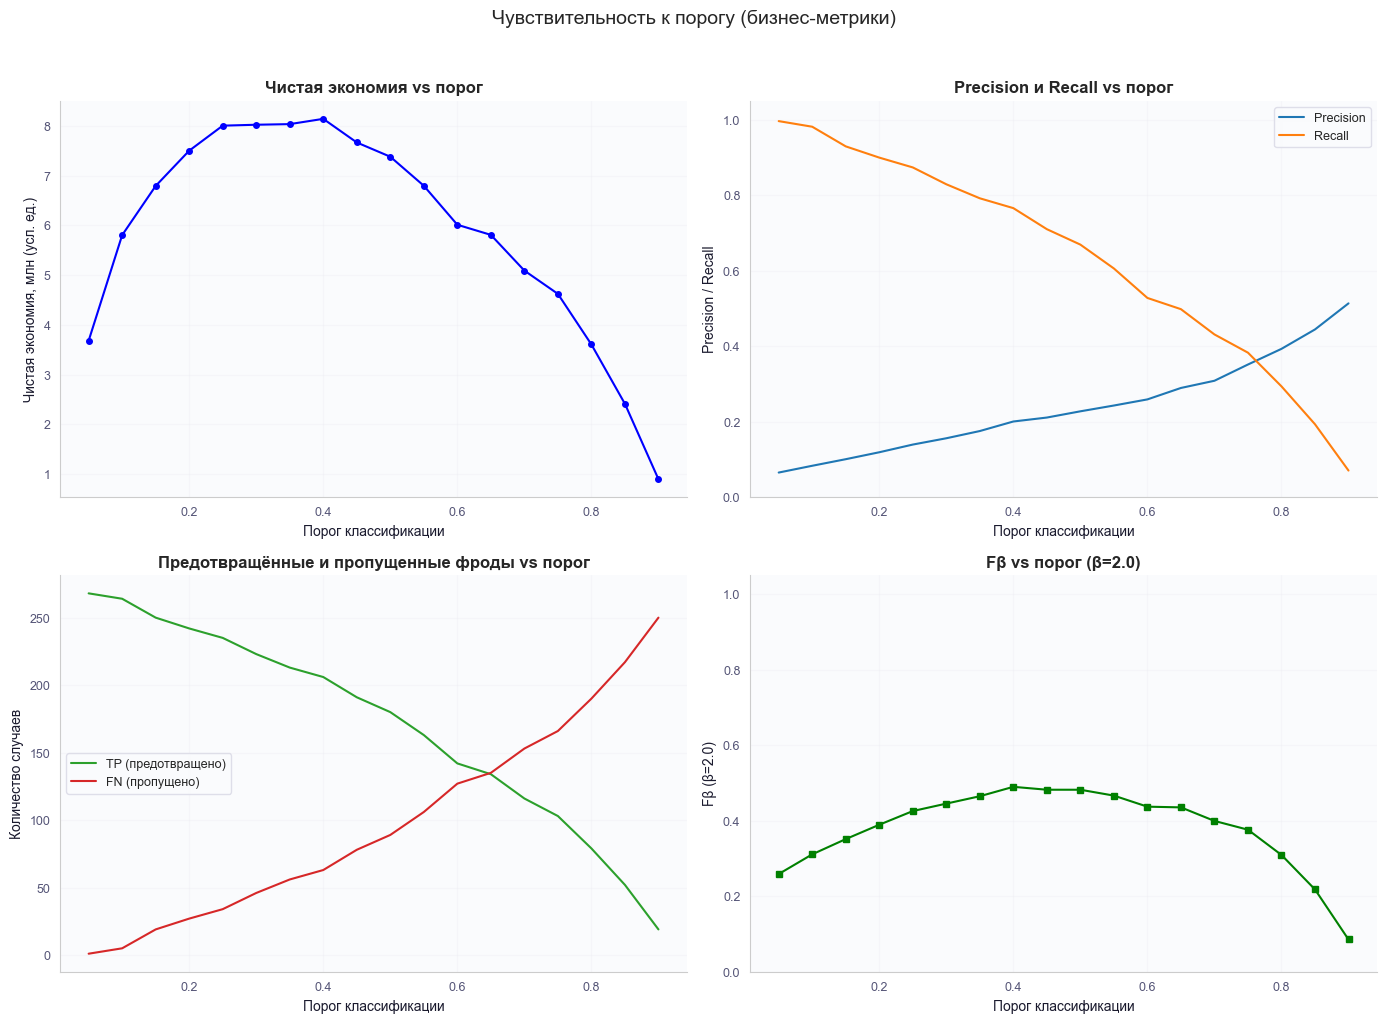

In [20]:
stage_16_business()


## 17. Итоговый отчёт

In [21]:
stage_17_report()



  --- Единый пересчёт метрик (те же y_val / y_test, порог с val) ---
                    ROC-AUC  PR-AUC  F_beta      F1      F2  Precision  Recall     FPR
LogReg               0.8387  0.3128  0.4128  0.3284  0.4128     0.2450  0.4981  0.0934
XGBoost              0.8579  0.3000  0.4838  0.3348  0.4838     0.2213  0.6877  0.1473
LightGBM             0.8567  0.3411  0.4704  0.3353  0.4704     0.2267  0.6431  0.1335
CatBoost             0.8617  0.3011  0.4821  0.3396  0.4821     0.2276  0.6691  0.1382
XGBoost+SMOTE        0.8228  0.2157  0.4387  0.2903  0.4387     0.1857  0.6654  0.1776
GraphSAGE            0.8706  0.3248  0.4976  0.3448  0.4976     0.2281  0.7063  0.1454
Autoencoder          0.5507  0.0989     NaN     NaN     NaN        NaN     NaN     NaN
NN_Classifier        0.8455  0.3114  0.4579  0.3587  0.4579     0.2635  0.5613  0.0955
BestEnsemble         0.8848  0.3619  0.5151  0.4009  0.5151     0.2928  0.6357  0.0934
BestEnsemble_no_NN   0.8831  0.3659  0.5274  0.4064  0.5274 